# Multivariate Regression

Let's grab a small little data set of Blue Book car values:

In [1]:
import pandas as pd

df = pd.read_excel('http://cdn.sundog-soft.com/Udemy/DataScience/cars.xls')


In [2]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


Mileage         Price
Mileage                                   
(0, 10000]       5588.629630  24096.714451
(10000, 20000]  15898.496183  21955.979607
(20000, 30000]  24114.407104  20278.606252
(30000, 40000]  33610.338710  19463.670267


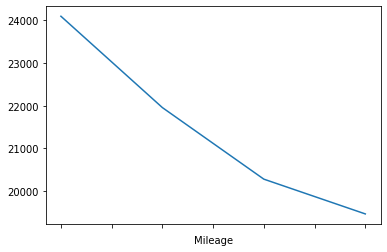

In [17]:
import numpy as np 
df1 = df[['Mileage','Price']]
bins = np.arange(0, 50000, 10000)
groups = df1.groupby(pd.cut(df1['Mileage'], bins)).mean()
print(groups.head())
groups['Price'].plot.line()

In [ ]:
We can see above, As Mileage increases, price decrease

We can use pandas to split up this matrix into the feature vectors we're interested in, and the value we're trying to predict.

Note how we are avoiding the make and model; regressions don't work well with
 
 " Ordinal values ", unless you can convert them into some numerical order that makes sense somehow.

Let's scale our feature data into the same range so we can easily compare the coefficients we end up with.

In [11]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()


## CONVENTION : X(upper) = feature variables | y(lower) = what we are going to predict
X = df[['Mileage', 'Cylinder', 'Doors']]  ## 3 feature variables 
y = df['Price']  ## what we are going to predict, i.e., Price i.e., Label Data

## Now we have to scale evrything down to a comparable range 
## we  normalize Mileage Cylinder Door Value into range between -1 & 1 using standard scaler and fit_transform coz Models work better with normalised data
## * it allows to compare the coeffs, this one having this effect relative to the others

X[['Mileage', 'Cylinder', 'Doors']] = scale.fit_transform(X[['Mileage', 'Cylinder', 'Doors']].values)

## technically it's scaled into a normal distribution, so some values may be outside the range(-1,1)
print(X)

est = sm.OLS(y, X).fit() ## ols = Ordinary Least Squares model

est.summary()

Mileage  Cylinder     Doors
0   -1.417485   0.52741  0.556279
1   -1.305902   0.52741  0.556279
2   -0.810128   0.52741  0.556279
3   -0.426058   0.52741  0.556279
4    0.000008   0.52741  0.556279
..        ...       ...       ...
799 -0.439853   0.52741  0.556279
800 -0.089966   0.52741  0.556279
801  0.079605   0.52741  0.556279
802  0.750446   0.52741  0.556279
803  1.932565   0.52741  0.556279

[804 rows x 3 columns]


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.064
Model:                            OLS   Adj. R-squared (uncentered):              0.060
Method:                 Least Squares   F-statistic:                              18.11
Date:                Sun, 24 May 2020   Prob (F-statistic):                    2.23e-11
Time:                        17:42:11   Log-Likelihood:                         -9207.1
No. Observations:                 804   AIC:                                  1.842e+04
Df Residuals:                     801   BIC:                                  1.843e+04
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Mileage    -1272.3412    804.623     -1.581      0.114   -2851.759     307.077
Cylinder    5587.4472    804.509      6.945      0.000    4008.252    7166.642
Doors      -1404.5513    804.275     -1.746      0.081   -2983.288     174.185
==============================================================================
Omnibus:                      157.913   Durbin-Watson:                   0.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              257.529
Skew:                           1.278   Prob(JB):                     1.20e-56
Kurtosis:                       4.074   Cond. No.                         1.03
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The table pf coeffs above gives us the values to plug into an equation of form:

        B0 + B1*Mileage + B2*model_ord + B3*doors
In this example, it's pretty clear that the number of cylinderes is more important tha anything based on the coefficients.

Could we have figured that out earlier ?

In [5]:
y.groupby(df.Doors).mean()   

Doors
2    23807.135520
4    20580.670749
Name: Price, dtype: float64

Surprisingly, more doors does not mean a higher price! (Maybe it implies a sport car in some cases?) So it's not surprising that it's pretty useless as a predictor here. This is a very small data set however, so we can't really read much meaning into it.

In [ ]:
(
    Mileage has coeff = -1272.3412 --- negative coeff
Cylinder has coeff = 5587.4472 --- positive coeff
By seeing the magnitude of coeffs tells that number of Cylinders is actually the most important feature to predict the price. the more the cylinders the more the Price.

Mileage is negative shows thats the lesser the mileage the more the Price. 
also doors has negative coeff so we can say that the lesser doors will have more the price. as in sports car are two doors though this is counter-intuitive
  )

How would you  use this to make an actual prediction ?

 Start by scaling your multiple feature variables into the same scale used to train the model, then just call est.predict() on the scaled features.

In [25]:
## to predict price of a car with 45000 miles 8 cylinders and 4 doors
## we have to scale the input features we are trying to predict for, in the same range we used to build the model. Using the same standard scaler instance and transform method.
scaled = scale.transform([[45000, 8, 4]])  
print(scaled)
predicted = est.predict(scaled[0])
print(predicted)

[[3.07256589 1.96971667 0.55627894]]
[6315.01330583]


In [ ]:
## There's also an inverse transform, to get back to initial values

## Activity

Mess around with the fake input data, and see if you can create a measurable influence of number of doors on price. Have some fun with it - why stop at 4 doors?